In [18]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sanidhyak/human-face-emotions")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'human-face-emotions' dataset.
Path to dataset files: /kaggle/input/human-face-emotions


In [19]:
import kagglehub
import os
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

path=kagglehub.dataset_download("sanidhyak/human-face-emotions")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'human-face-emotions' dataset.
Path to dataset files: /kaggle/input/human-face-emotions


#1.Load and visualize at least 5 images from the 'Happy' dataset

Found 100 images from the 'Happy' dataset. Displaying the first 5:


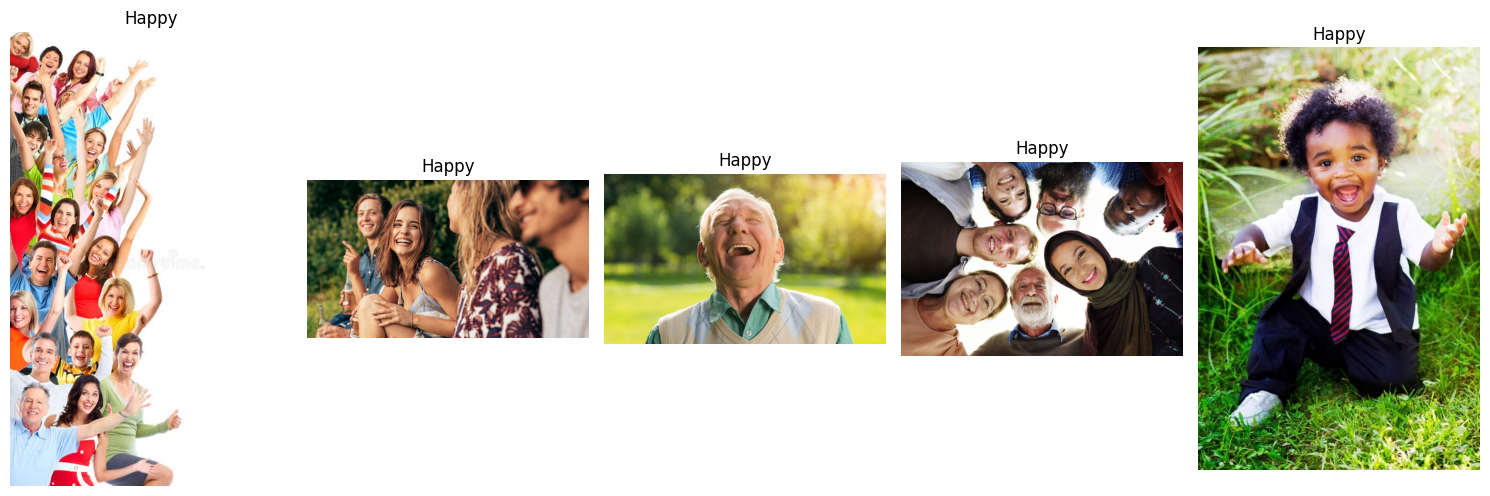

In [20]:
#Load and visualize at least 5 images from the 'Happy' dataset
import os
import cv2
import matplotlib.pyplot as plt

image_paths = []
IMAGE_EXTENSIONS = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')

# Construct the path to the 'Happy' subdirectory
happy_dataset_path = os.path.join(path, 'data', 'Happy')

if not os.path.exists(happy_dataset_path):
    print(f"Error: The 'Happy' dataset path does not exist: {happy_dataset_path}")
else:
    # Collect all image files specifically from the 'Happy' directory
    # Removed the limit to collect only 5 images
    for root, dirs, files in os.walk(happy_dataset_path):
        for file in files:
            if file.lower().endswith(IMAGE_EXTENSIONS):
                image_paths.append(os.path.join(root, file))

    if not image_paths:
        print("No image files found in the 'Happy' dataset.")
    else:
        # Limit to 5 images for visualization to prevent overwhelming the display
        images_to_display = image_paths[:5]
        print(f"Found {len(image_paths)} images from the 'Happy' dataset. Displaying the first {len(images_to_display)}:")
        plt.figure(figsize=(15, 10))
        for i, img_path in enumerate(images_to_display):
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert BGR to RGB for matplotlib
            plt.subplot(1, len(images_to_display), i + 1)
            plt.imshow(img)
            plt.title(os.path.basename(os.path.dirname(img_path))) # Display folder name as title
            plt.axis('off')
        plt.tight_layout()
        plt.show()


###2.Extract image height, width, and channels and store in a table

In [21]:
#Extract image height, width, and channels and store in a table
data=[]
for img_path in image_paths:
    img=cv2.imread(img_path)
    height,width,channels=img.shape
    data.append([img_path,height,width,channels])

df=pd.DataFrame(data,columns=['Image Path','Height','Width','Channels'])
df.head(20)

,Image Path,Height,Width,Channels
0,/kaggle/input/human-face-emotions/data/Happy/g...,900,559,3
1,/kaggle/input/human-face-emotions/data/Happy/f...,900,1600,3
2,/kaggle/input/human-face-emotions/data/Happy/4...,1146,1908,3
3,/kaggle/input/human-face-emotions/data/Happy/G...,966,1400,3
4,/kaggle/input/human-face-emotions/data/Happy/9...,960,640,3
5,/kaggle/input/human-face-emotions/data/Happy/i...,183,275,3
6,/kaggle/input/human-face-emotions/data/Happy/i...,162,311,3
7,/kaggle/input/human-face-emotions/data/Happy/g...,2920,5184,3
8,/kaggle/input/human-face-emotions/data/Happy/D...,1115,2000,3
9,/kaggle/input/human-face-emotions/data/Happy/i...,1481,1000,3


#3.Resize all images to 224×224 pixels.

In [22]:
#Resize all images to 224×224 pixels.
resized_images=[]

for img_path in image_paths:
    img=cv2.imread(img_path)
    resized_img=cv2.resize(img,(224,224))
    resized_images.append(resized_img)

print("total resized images:",len(resized_images))
print("resized image shape:",resized_images[0].shape)

total resized images: 100
resized image shape: (224, 224, 3)


### 4. Convert images to Grayscale, RGB, and HSV.

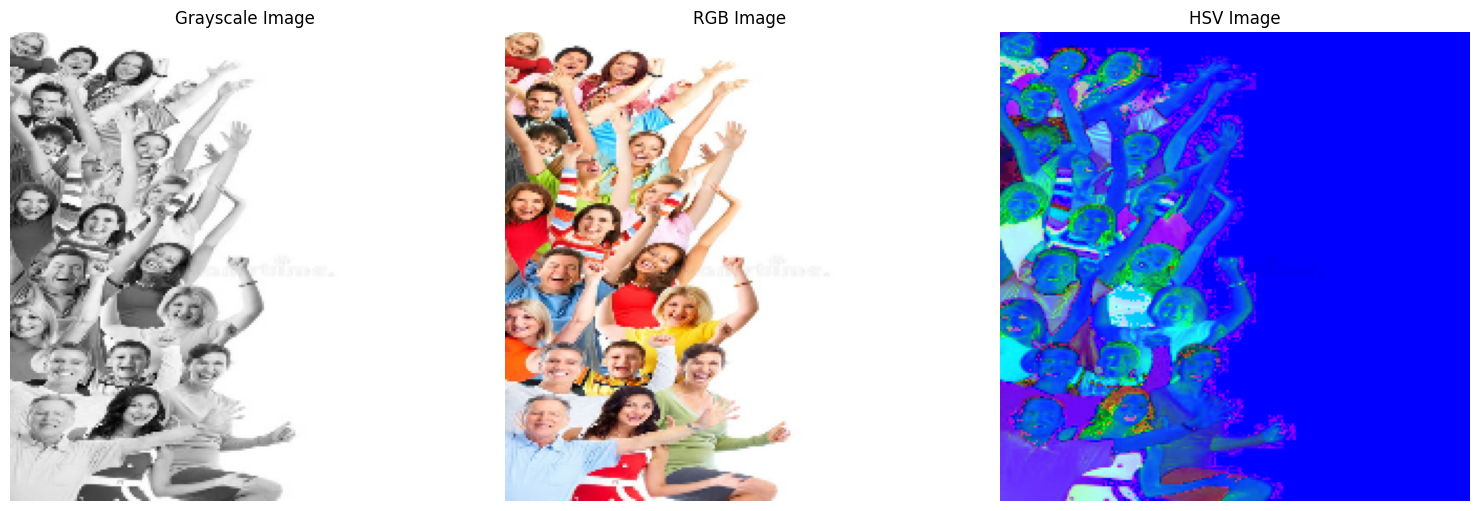

In [23]:
grayscale_images = []
rgb_images = []
hsv_images = []

for img in resized_images:
    # Convert to Grayscale
    gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    grayscale_images.append(gray_img)

    # Convert to RGB (OpenCV reads as BGR, so convert to RGB for matplotlib)
    rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    rgb_images.append(rgb_img)

    # Convert to HSV
    hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    hsv_images.append(hsv_img)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(grayscale_images[0], cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(rgb_images[0])
plt.title('RGB Image')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(hsv_images[0])
plt.title('HSV Image')
plt.axis('off')

plt.tight_layout()
plt.show()

##5. Normalize pixel values from 0–255 to 0–1.

In [24]:
normalized_images = []

for img in resized_images:
    normalized_images.append(img / 255.0)

print(f"Number of normalized images: {len(normalized_images)}")
print(f"First normalized image shape: {normalized_images[0].shape}")
print(f"First normalized image pixel value example: {normalized_images[0][0][0]}")

Number of normalized images: 100
First normalized image shape: (224, 224, 3)
First normalized image pixel value example: [1.         0.99607843 0.98823529]


##Perform Data Augmentation (rotation, flips, zoom, brightness adjustment).

In [25]:
from PIL import Image, ImageEnhance, ImageOps
#PIL: Python Imaging Library (via Pillow), used for image processing.
#Image: Handles image loading, saving, and manipulation.
#ImageEnhance: Provides tools for enhancing image properties like brightness and contrast.
#ImageOps: Contains image processing utilities, such as flipping and grayscaling.
#os: A module to handle file system operations like creating directories and file paths.

import os

# Load the uploaded image
image_path = image_paths[0]  # Using the first image from the 'Happy' dataset
image = Image.open(image_path)

# Create a directory for augmented images
augmented_dir = "augmented_images"
#Creates the directory augmented_images
os.makedirs(augmented_dir, exist_ok=True)
 #Ensures no error is raised if the directory already exists.

# Augmentation functions
def augment_image(image, output_dir):
    # 1. Horizontal Flip
    # Flips the image horizontally (mirroring).
    flipped = ImageOps.mirror(image)
    #Saves the flipped image as flipped.jpeg in the output_dir
    flipped.save(os.path.join(output_dir, "flipped.jpeg"))

    # 2. Rotate
    rotated = image.rotate(30)
    #Rotates the image by 30 degrees (counterclockwise by default)
    rotated.save(os.path.join(output_dir, "rotated.jpeg"))

    # 3. Brightness Adjustment
    enhancer = ImageEnhance.Brightness(image)
    #Adjusts brightness by a factor of 1.5 (1.0 = original brightness).
    brighter = enhancer.enhance(1.5)
    brighter.save(os.path.join(output_dir, "brighter.jpeg"))

    # 4. Contrast Adjustment
    contrast = ImageEnhance.Contrast(image).enhance(2.0)
    #Doubles the image's contrast (2.0 = twice the original contrast).

    contrast.save(os.path.join(output_dir, "contrast.jpeg"))

    # 5. Grayscale
    grayscale = ImageOps.grayscale(image)
    grayscale.save(os.path.join(output_dir, "grayscale.jpeg"))

# Apply augmentations
augment_image(image, augmented_dir)
#Calls the augment_image function to apply all augmentations on the loaded image and save the results in the augmented_images directory.

# List the augmented files
print("Augmented images saved in:", augmented_dir)
print("Generated files:", os.listdir(augmented_dir))

Augmented images saved in: augmented_images
Generated files: ['contrast.jpeg', 'flipped.jpeg', 'brighter.jpeg', 'grayscale.jpeg', 'rotated.jpeg']


Now, let's create a reusable `preprocess_image()` function that encapsulates the resizing and normalization steps.

In [26]:
def preprocess_image(image_path, target_size=(224, 224)):
    """
    Loads an image from the given path, resizes it, and normalizes its pixel values.

    Args:
        image_path (str): The path to the image file.
        target_size (tuple): The desired (width, height) for the resized image.

    Returns:
        numpy.ndarray: The preprocessed image as a NumPy array with pixel values in [0, 1].
    """
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Image not found at {image_path}")

    # Resize the image
    resized_img = cv2.resize(img, target_size)

    # Normalize pixel values from 0-255 to 0-1
    normalized_img = resized_img / 255.0

    return normalized_img

print("preprocess_image() function defined.")

preprocess_image() function defined.


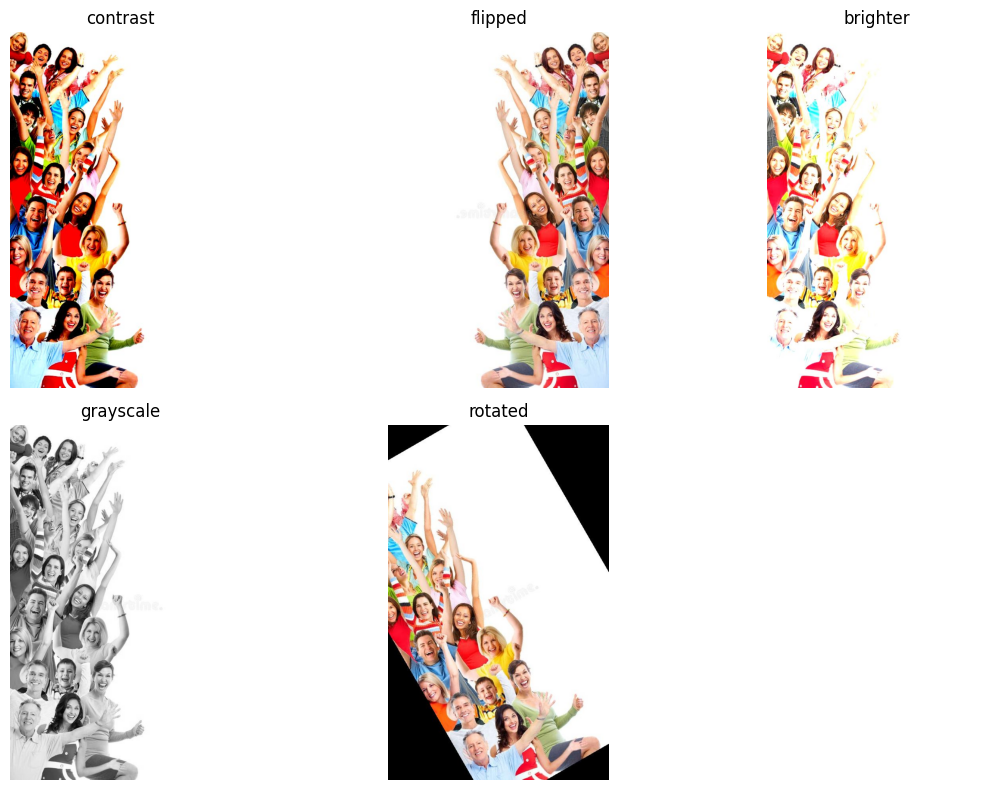

In [27]:
from PIL import Image
#used to open and manipulate images
import matplotlib.pyplot as plt
import os

#directory where augmented images are stored
augmented_dir="augmented_images"
augmented_images=os.listdir(augmented_dir)

#list allaugmented images files
plt.figure(figsize=(12,8))  #adjust the size of the plot

for i,img_file in enumerate(augmented_images):
  img_path=os.path.join(augmented_dir,img_file)
  img=Image.open(img_path)
  plt.subplot(2,3,i+1)
  plt.imshow(img,cmap="gray" if img.mode=="L" else None)
  plt.title(img_file.split('.')[0]) #use file nams as title
  plt.axis("off") #hide axes

plt.tight_layout()
plt.show()

##10.Create a reusable preprocess_image() function.

In [28]:
import tensorflow as tf

def preprocess_image(image_path, img_size=(224, 224)):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_image(img, channels=3)
    img = tf.image.resize(img, img_size)
    img = tf.cast(img, tf.float32) / 255.0
    return img

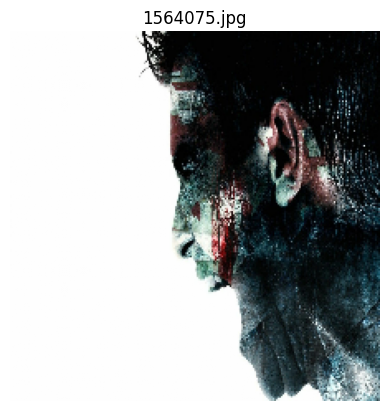

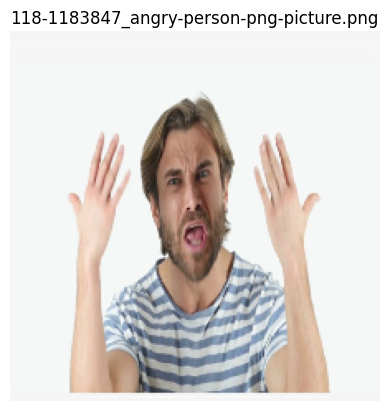

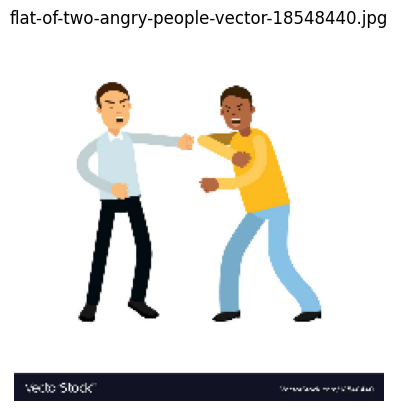

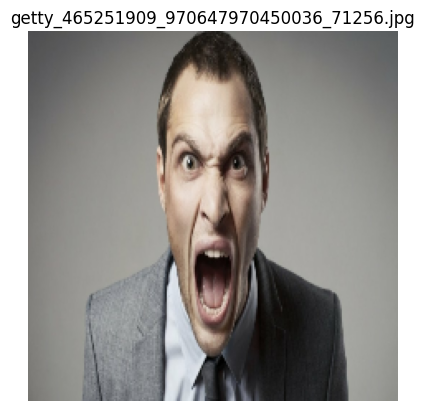

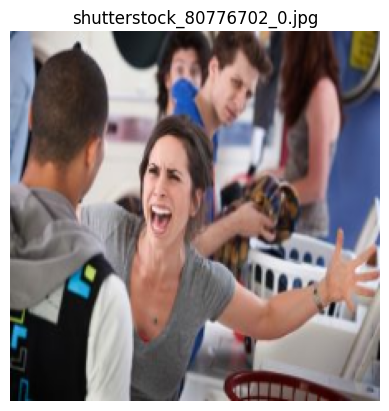

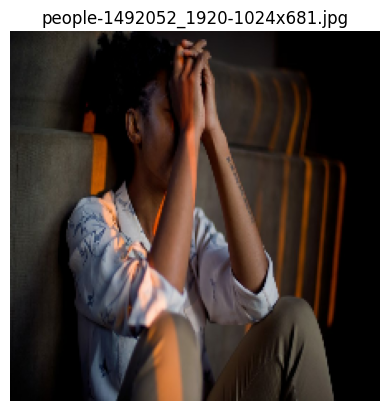

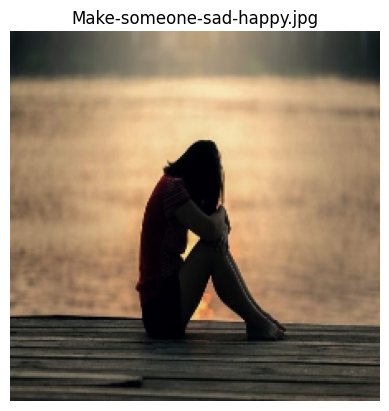

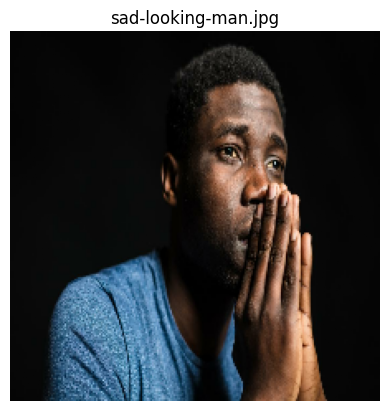

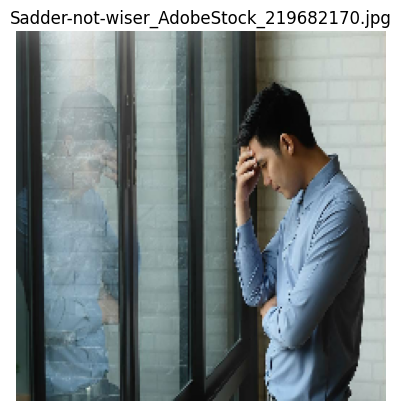

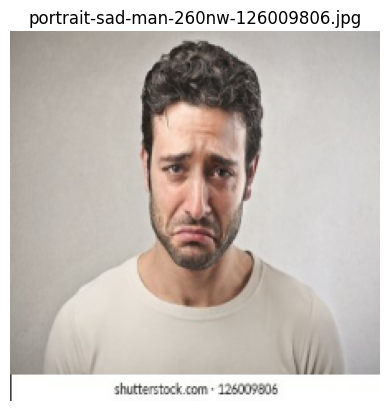

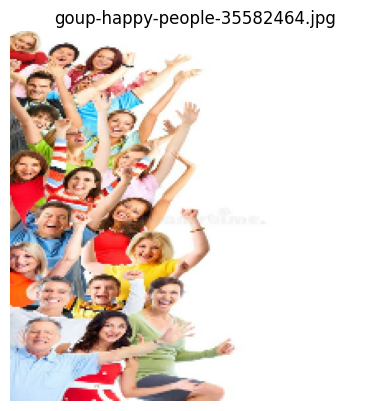

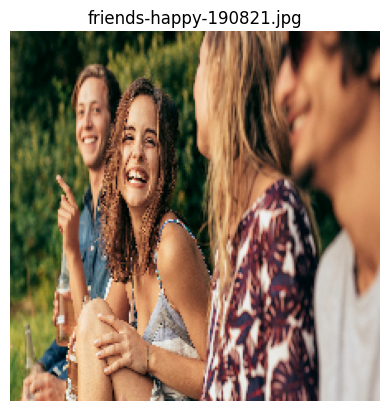

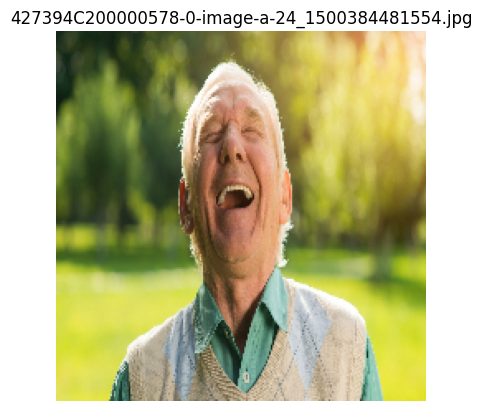

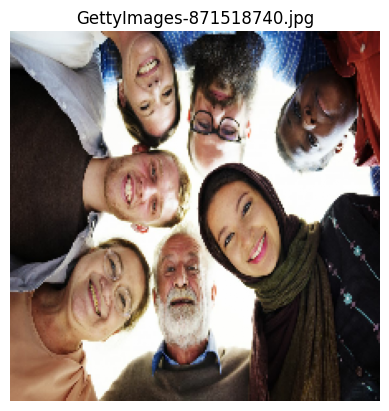

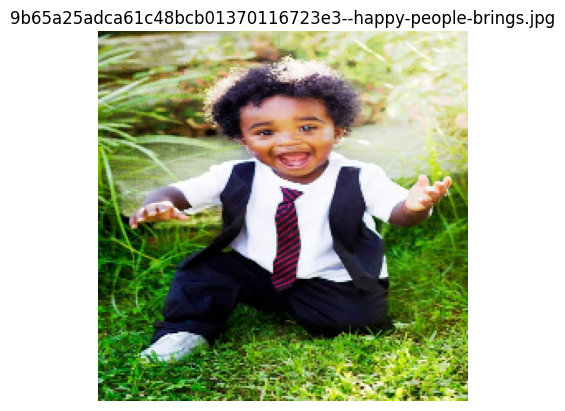

In [29]:
import os

# Use the 'path' variable which holds the correct dataset path
dataset_path = path

for root, _, files in os.walk(dataset_path):
    for file in files[:5]:  # first 5 images
        if file.lower().endswith(('.jpg', '.png', '.jpeg')):
            path = os.path.join(root, file)

            img = preprocess_image(path)

            plt.imshow(img)
            plt.title(file)
            plt.axis("off")
            plt.show()